In [106]:
import json
import os

import numpy as np
import pandas as pd

dir = '../large_files/new_beam_matching_experiment_1nrec'
#dir = '../data/results/experiments/new_beam_matching_experiment_15'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['n_best_pcis'] = data_df['n_best_pcis'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')
data_df['n_best_beams'] = data_df['n_best_beams'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')


#data_df['runtime'] = data_df['runtime'] * 1000 / 2500


def get_strat(row):
    if row['n_best_pcis'] == 'all' and row['n_best_beams'] == 'all':
        return 'All PCIs and all beams'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == 'all':
        return 'Only best PCI and all beams'
    elif row['n_best_pcis'] == 'all' and row['n_best_beams'] == '1':
        return 'All PCIs and only best beam'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == '1':
        return 'Only best PCI and only best beam'
    return 'unknown strategy'


data_df['config'] = data_df.apply(get_strat, axis=1)

data_df


,errors,complexity,run,n_best_pcis,n_best_beams,config
0,2.221874,3373656.0,0.0,all,all,All PCIs and all beams
1,3.023250,3373656.0,0.0,all,all,All PCIs and all beams
2,0.274133,3373656.0,0.0,all,all,All PCIs and all beams
3,9.892799,3373656.0,0.0,all,all,All PCIs and all beams
4,6.301775,3373656.0,0.0,all,all,All PCIs and all beams
...,...,...,...,...,...,...
5843987,6.713752,2820978.0,14.0,19,8,unknown strategy
5843988,3.406828,2820978.0,14.0,19,8,unknown strategy
5843989,16.666779,2820978.0,14.0,19,8,unknown strategy
5843990,0.802257,2820978.0,14.0,19,8,unknown strategy


In [138]:


entries = [str(i) for i in range(5, 30)]
data = data_df[data_df['n_best_pcis'].isin(entries)]

data['n_best_pcis'] = data['n_best_pcis'].apply(lambda x: int(x))
#data = data[data['n_best_beams'] == '1']

comps = data.groupby(['n_best_beams'])['complexity'].mean().values


def calculate_percentage_increase(numbers):
    percentage_increases = []
    for i in range(1, len(numbers)):
        previous_number = numbers[i - 1]
        current_number = numbers[i]
        if previous_number != 0:
            increase = ((current_number - previous_number) / previous_number) * 100
        else:
            increase = float('inf')  # Handle division by zero if needed
        percentage_increases.append(increase)
    return percentage_increases


comps = [int(c) for c in comps]

print(comps)

percs = calculate_percentage_increase(comps)
print(percs[1:])
print(np.array(percs[1:]).mean())

[1654297, 2073266, 2230967, 2294127, 2314918, 2329433, 2333748, 2336102]
[7.606404580984784, 2.8310593567721978, 0.9062706641785743, 0.6270200499542532, 0.18523821032843613, 0.10086778863870478]
2.0428101084761585


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_26961/2276288724.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['n_best_pcis'] = data['n_best_pcis'].apply(lambda x: int(x))


In [140]:
# Calculate the mean of 'errors' for each 'config'


#data = data_df[data_df['operator'].isin([10])]
data = data_df
res = data.groupby('config')['complexity'].median()

# Extract specific configurations
ap_ab = res['All PCIs and all beams']  # Most comprehensive
ap_bb = res['All PCIs and only best beam']
bp_ab = res['Only best PCI and all beams']
bp_bb = res['Only best PCI and only best beam']  # Least comprehensive

print(f'ap_ab {ap_ab}')  # most comprehensive
print(f'ap_bb {ap_bb}')
print(f'bp_ab {bp_ab}')
print(f'bp_bb {bp_bb}')  # least comprehensive

# Calculate the percentage increase
(ap_bb - ap_ab) / ap_ab * 100

KeyError: 'Only best PCI and all beams'

In [40]:
res = []
for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams']):
    errors = data.groupby('run')['errors'].mean().values
    complexity = data.groupby('run')['complexity'].mean().values
    print(group)
    for i in range(errors.shape[0]):
        res.append((group[0], group[1], errors[i], complexity[i]))

order = [str(x) for x in range(1, 20)] + ['all']

df = pd.DataFrame(res,
                  columns=['n_best_pcis', 'n_best_beams', 'errors', 'complexity'])
df['n_best_pcis'] = pd.Categorical(df['n_best_pcis'], categories=order, ordered=True)
df.sort_values(by=['n_best_pcis', 'n_best_beams'], inplace=True)

df[df['n_best_pcis'] == 'all']['errors'].mean()

# res = []
# for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams', 'operator', 'config']):
#     errors = data.groupby('run')['errors'].mean().values
#     complexity = data.groupby('run')['complexity'].mean().values
#     runtime = data.groupby('run')['runtime'].mean().values
#
#     for i in range(errors.shape[0]):
#         res.append((group[0], group[1], group[2], errors[i], complexity[i], group[3], runtime[i]))
#
# order = [str(x) for x in range(1, 20)] + ['all']
#
# df = pd.DataFrame(res,
#                   columns=['n_best_pcis', 'n_best_beams', 'operator', 'errors', 'complexity', 'config', 'runtime'])
# df['n_best_pcis'] = pd.Categorical(df['n_best_pcis'], categories=order, ordered=True)
# df.sort_values(by=['n_best_pcis', 'n_best_beams'], inplace=True)
#
# df[df['n_best_pcis'] == 'all']['errors'].mean()
#
# df.groupby(['operator', 'config'])['errors'].mean()

('1', '1')
('1', '2')
('1', '3')
('1', '4')
('1', '5')
('1', '6')
('1', '7')
('1', '8')
('10', '1')
('10', '2')
('10', '3')
('10', '4')
('10', '5')
('10', '6')
('10', '7')
('10', '8')
('11', '1')
('11', '2')
('11', '3')
('11', '4')
('11', '5')
('11', '6')
('11', '7')
('11', '8')
('12', '1')
('12', '2')
('12', '3')
('12', '4')
('12', '5')
('12', '6')
('12', '7')
('12', '8')
('13', '1')
('13', '2')
('13', '3')
('13', '4')
('13', '5')
('13', '6')
('13', '7')
('13', '8')
('14', '1')
('14', '2')
('14', '3')
('14', '4')
('14', '5')
('14', '6')
('14', '7')
('14', '8')
('15', '1')
('15', '2')
('15', '3')
('15', '4')
('15', '5')
('15', '6')
('15', '7')
('15', '8')
('16', '1')
('16', '2')
('16', '3')
('16', '4')
('16', '5')
('16', '6')
('16', '7')
('16', '8')
('17', '1')
('17', '2')
('17', '3')
('17', '4')
('17', '5')
('17', '6')
('17', '7')
('17', '8')
('18', '1')
('18', '2')
('18', '3')
('18', '4')
('18', '5')
('18', '6')
('18', '7')
('18', '8')
('19', '1')
('19', '2')
('19', '3')
('19', '4')


np.float64(4.866634272216346)

In [51]:
one = df[df['n_best_pcis'] == '1']['errors'].mean()
two = df[df['n_best_pcis'] == '2']['errors'].mean()

print(f'one: {one} to two: {two}')

print(f'Decrease in error from one to two pcis, {int((one - two) / one * 100)} %')

one: 29.802582350519597 to two: 18.549988912814523
Decrease in error from one to two pcis, 37 %


In [63]:
print(f"2-3 beam improvement for low PCI scenarios")

data = df[df['n_best_pcis'].isin([str(i) for i in range(1, 5)])]

ones = data[data['n_best_beams'] == '1']['errors'].mean()
twos = data[data['n_best_beams'] == '2']['errors'].mean()
fives = data[data['n_best_beams'] == '5']['errors'].mean()

print(f'Error decrease from one to two best beams is {(ones - twos) / ones * 100} %')

print(f'Error increase from two to five best beams is {(twos - fives) / twos * 100} %')

print('Beam 1-2 improvement in all PCI scenarios:')

ones = df[df['n_best_beams'] == '1']['errors'].mean()
twos = df[df['n_best_beams'] == '2']['errors'].mean()
print(f'Error decrease from one to two best beams is {(ones - twos) / ones * 100} %')

2-3 beam improvement for low PCI scenarios
Error decrease from one to two best beams is 18.96340378290076 %
Error increase from two to five best beams is 5.1984799581828804 %
Beam 1-2 improvement in all PCI scenarios:
Error decrease from one to two best beams is 15.837308019585928 %


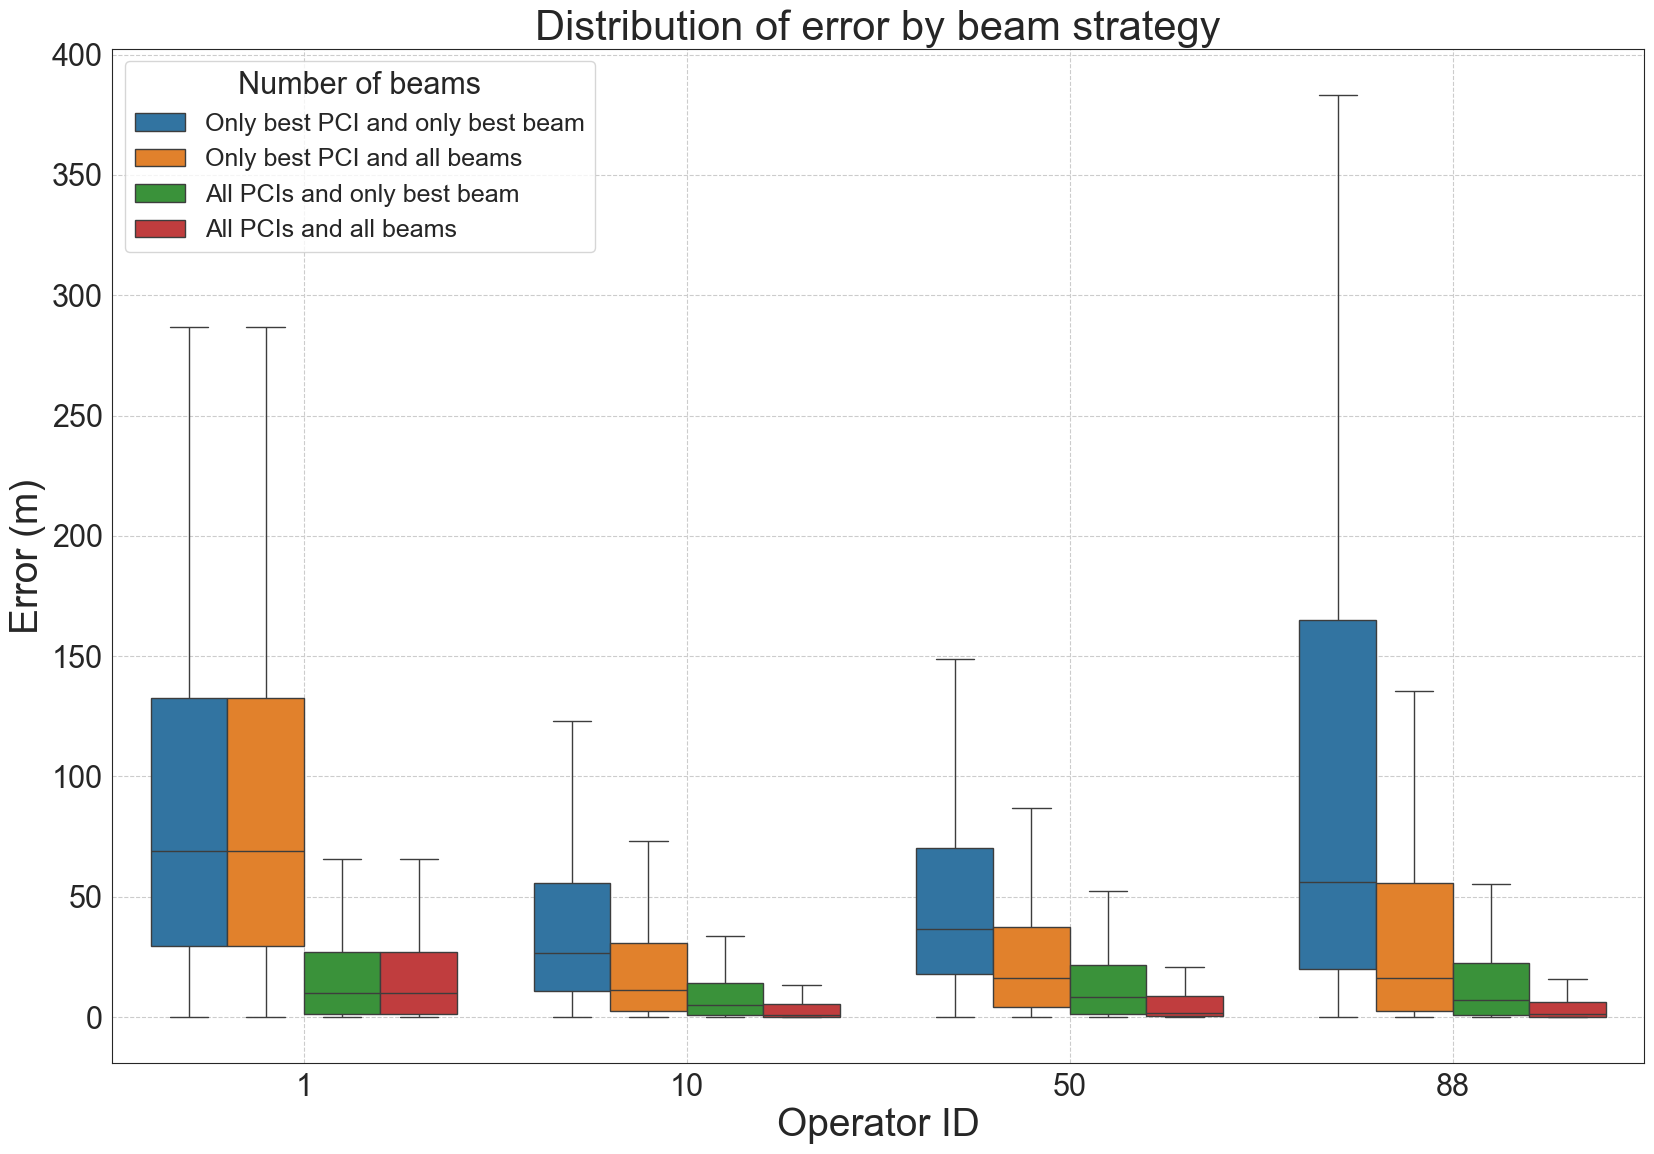

In [25]:


import pandas as pd
from matplotlib.ticker import FuncFormatter


def plot_operator(
        df: pd.DataFrame,
        y: str,
        x_label: str,
        y_label: str,
        title: str,
):
    plt.rcParams.update({"font.size": 22})

    hue_order = [
        'Only best PCI and only best beam',
        'Only best PCI and all beams',
        'All PCIs and only best beam',
        'All PCIs and all beams',
    ]

    plt.figure(figsize=(17, 12))

    sns.set_style("white")

    box = True
    if box:
        bar_plot = sns.boxplot(
            data=df,
            x='operator',
            y=y,
            hue='config',
            hue_order=hue_order,
            showfliers=False,
        )


    else:
        bar_plot = sns.barplot(
            data=df,
            x='operator',
            y=y,
            hue='config',
            hue_order=hue_order,
        )
        # Annotate each bar
        for p in bar_plot.patches:
            height = p.get_height()
            if height != 0:  # Check if the height is not zero
                bar_plot.annotate(f'{height:,.2f}',
                                  (p.get_x() + p.get_width() / 2., height),
                                  ha='center', va='center',
                                  fontsize=18, color='black', xytext=(0, 10),
                                  textcoords='offset points')

    # Format y-axis in thousands
    formatter = FuncFormatter(lambda x, _: f'{x / 1000:,.0f}k')
    #plt.gca().yaxis.set_major_formatter(formatter)

    # Add labels and title
    plt.xlabel(x_label, fontsize=28)
    plt.ylabel(y_label, fontsize=28)
    plt.title(title, fontsize=30)

    plt.legend(title='Number of beams', loc='upper left', fontsize=18)
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


plot_operator(data_df, 'errors', 'Operator ID', 'Error (m)', 'Distribution of error by beam strategy')
#plot_operator(data_df, 'complexity', 'Operator ID', 'Complexity', 'Complexity by beam strategy')
#plot_operator(data_df, 'runtime', 'Operator ID', 'Runtime per TP (ms)', 'Runtime by beam strategy')


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_26961/3124289645.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lows['n_best_pcis'] = pd.Categorical(df_lows['n_best_pcis'], categories=lows, ordered=True)
/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_26961/3124289645.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_highs['n_best_pcis'] = pd.Categorical(df_highs['n_best_pcis'], categories=highs, ordered=True)


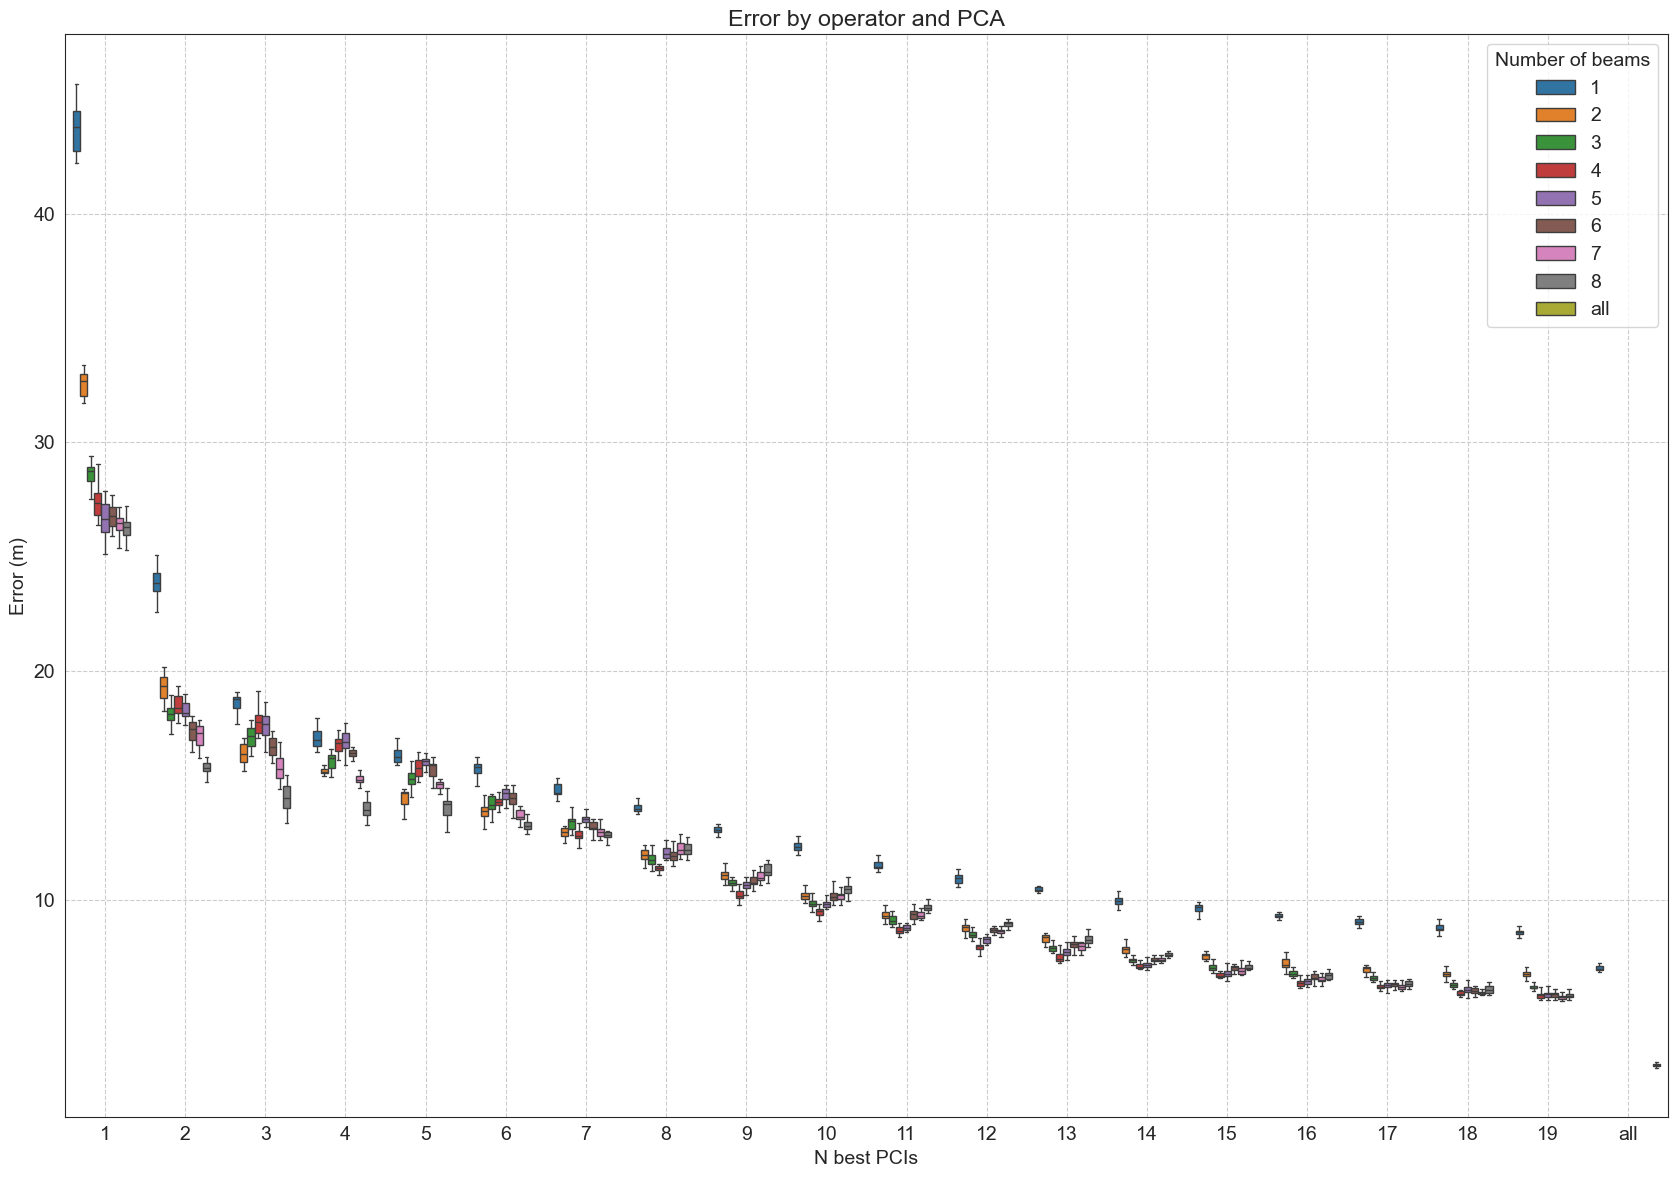

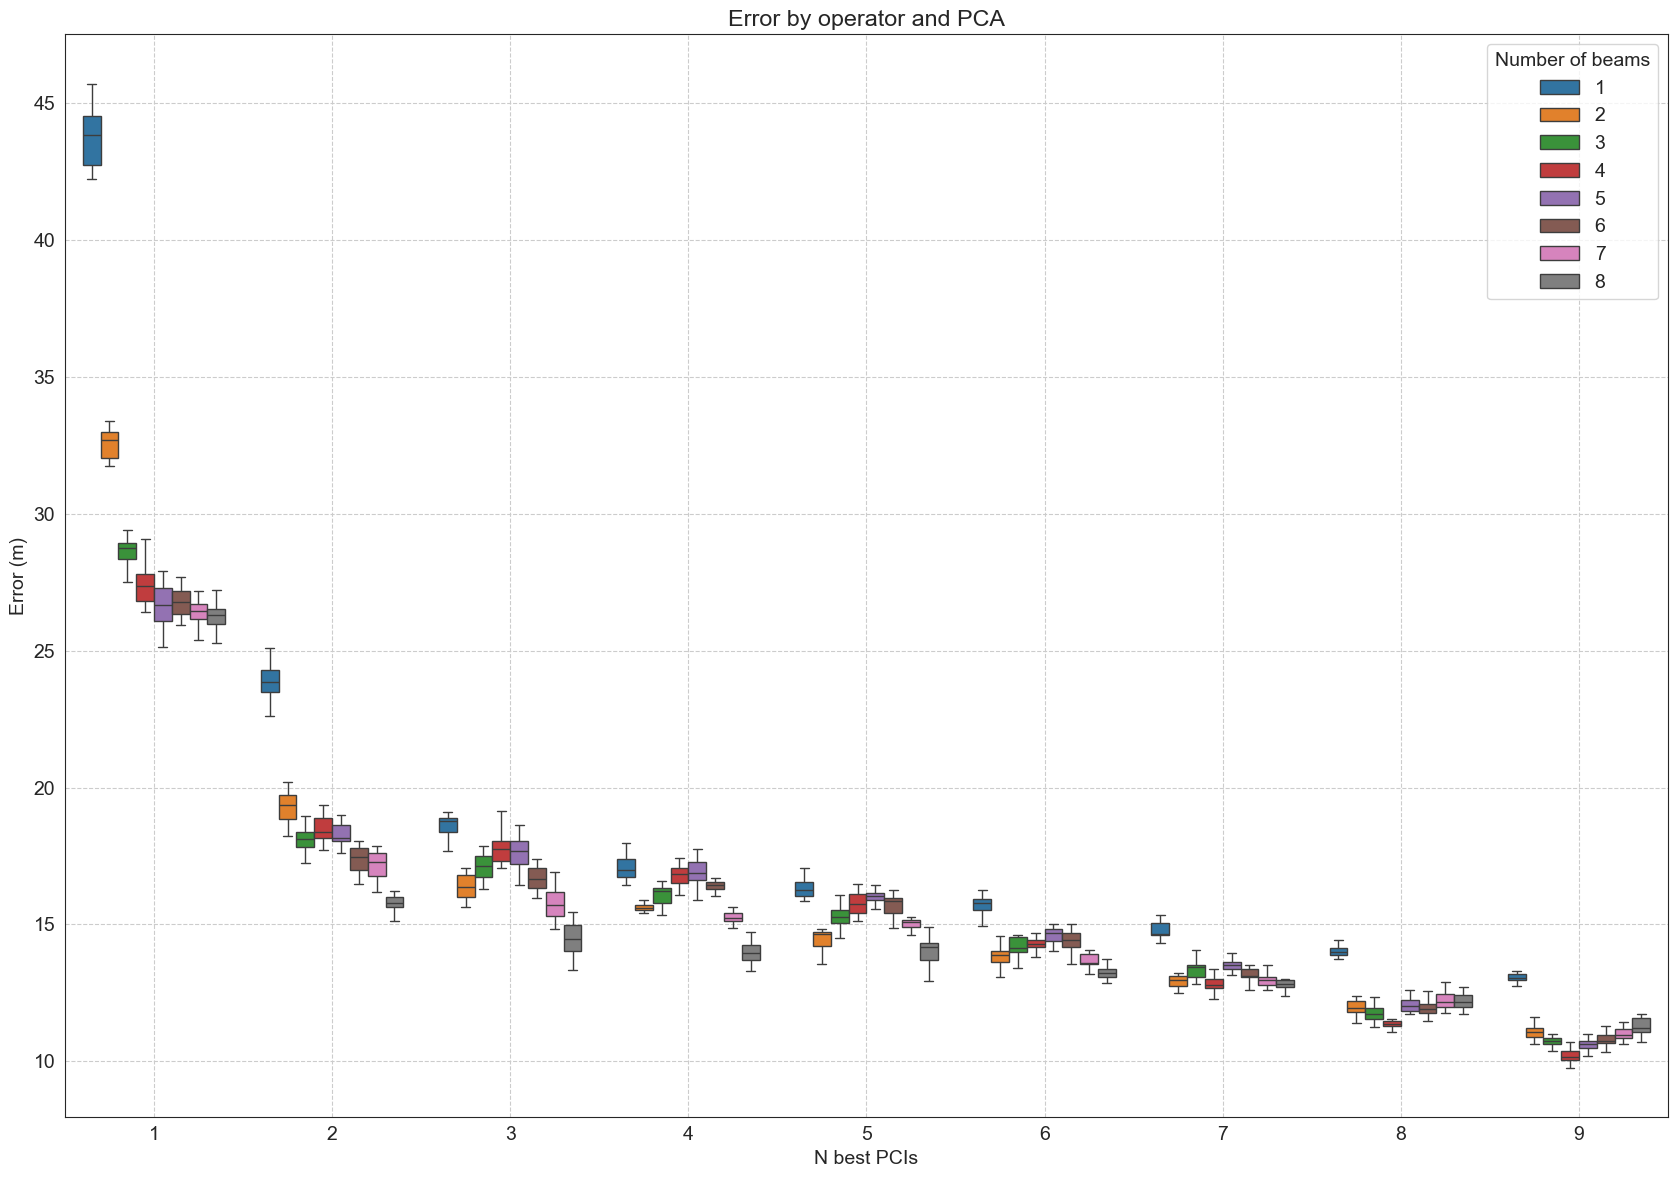

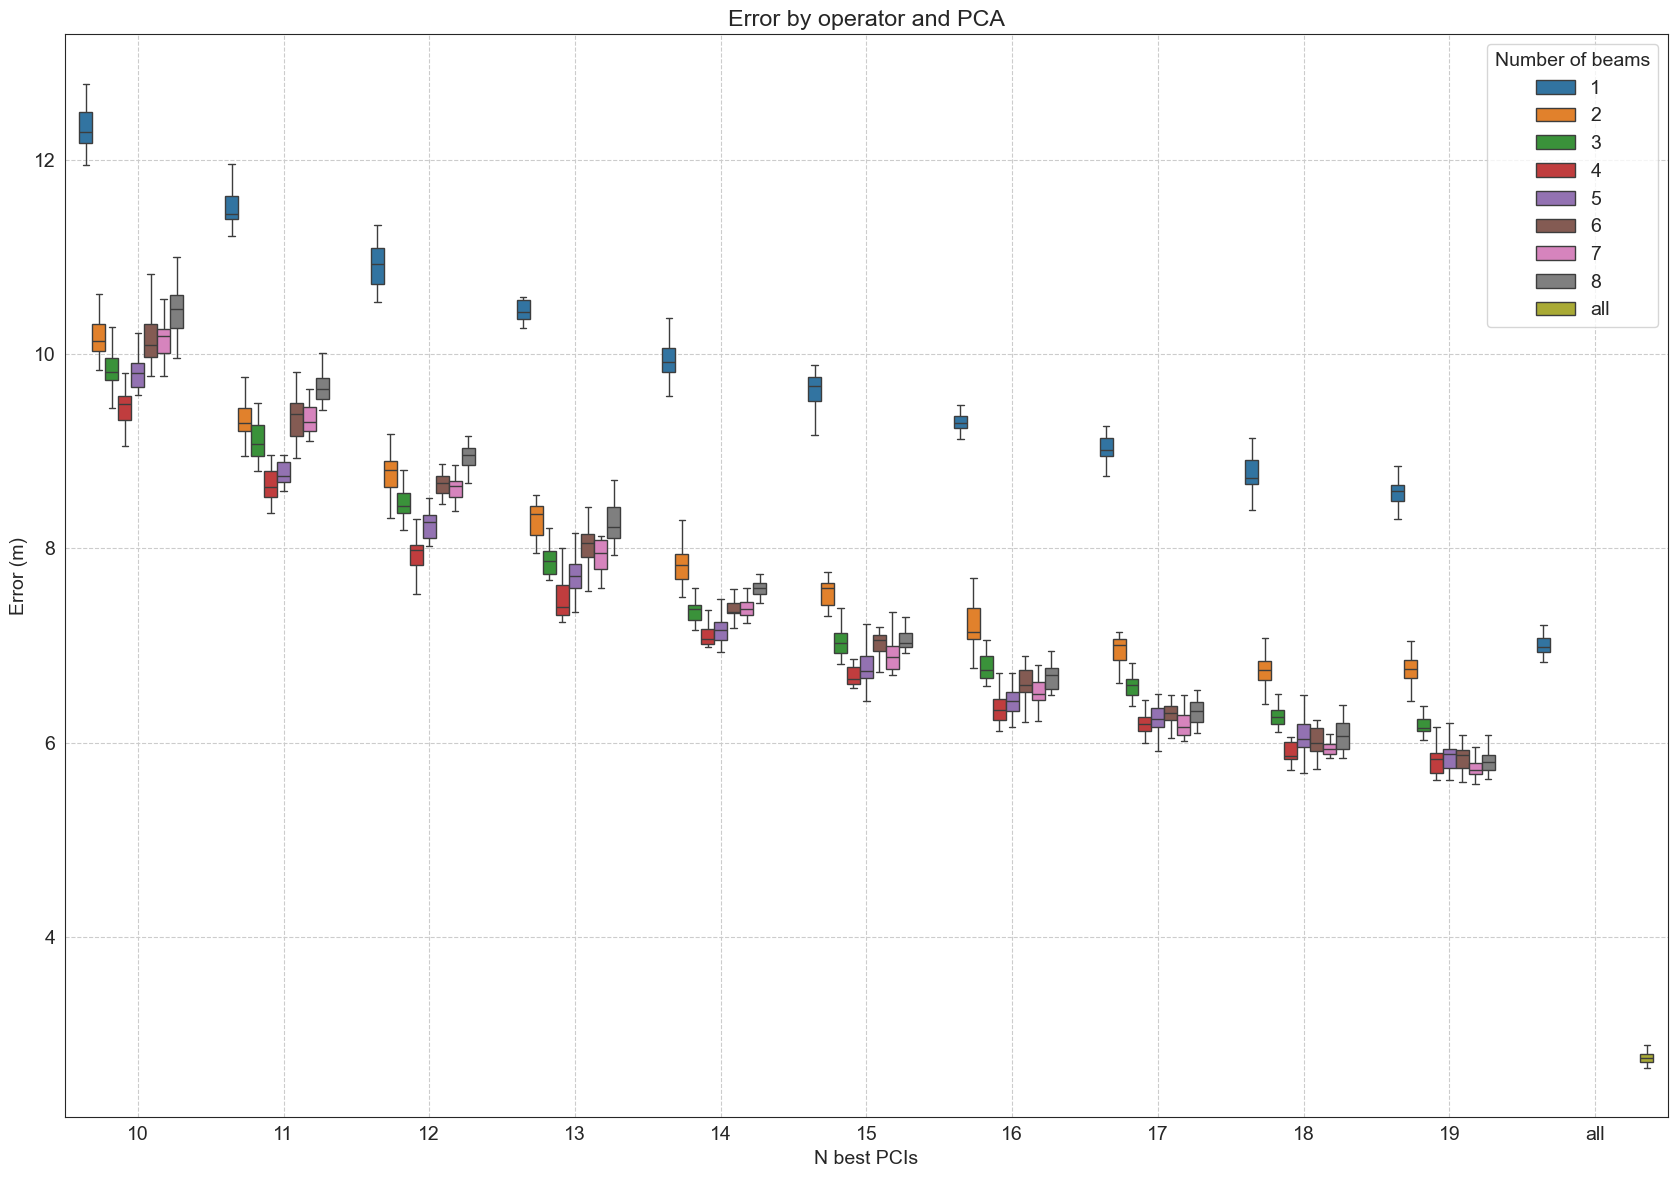

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 14})

    # baseline = df[df['n_best_pcis'] == 'all']['errors'].mean()
    #
    # data = df[df['n_best_pcis'] != 'all']

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
    )

    #plt.axhline(y=baseline, color='r', linestyle='--')

    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 20)] + ['all']
lows = [str(i) for i in range(1, 10)]


#plot(data_df[data_df['n_best_pcis'].isin(highs)])
#plot(data_df[data_df['n_best_pcis'].isin(lows)])

def do_plot(df):
    df_lows = df[df['n_best_pcis'].isin(lows)]
    df_lows['n_best_pcis'] = pd.Categorical(df_lows['n_best_pcis'], categories=lows, ordered=True)

    df_highs = df[df['n_best_pcis'].isin(highs)]
    df_highs['n_best_pcis'] = pd.Categorical(df_highs['n_best_pcis'], categories=highs, ordered=True)

    # plot the points
    plot(df)
    plot(df_lows)
    plot(df_highs)


do_plot(df)

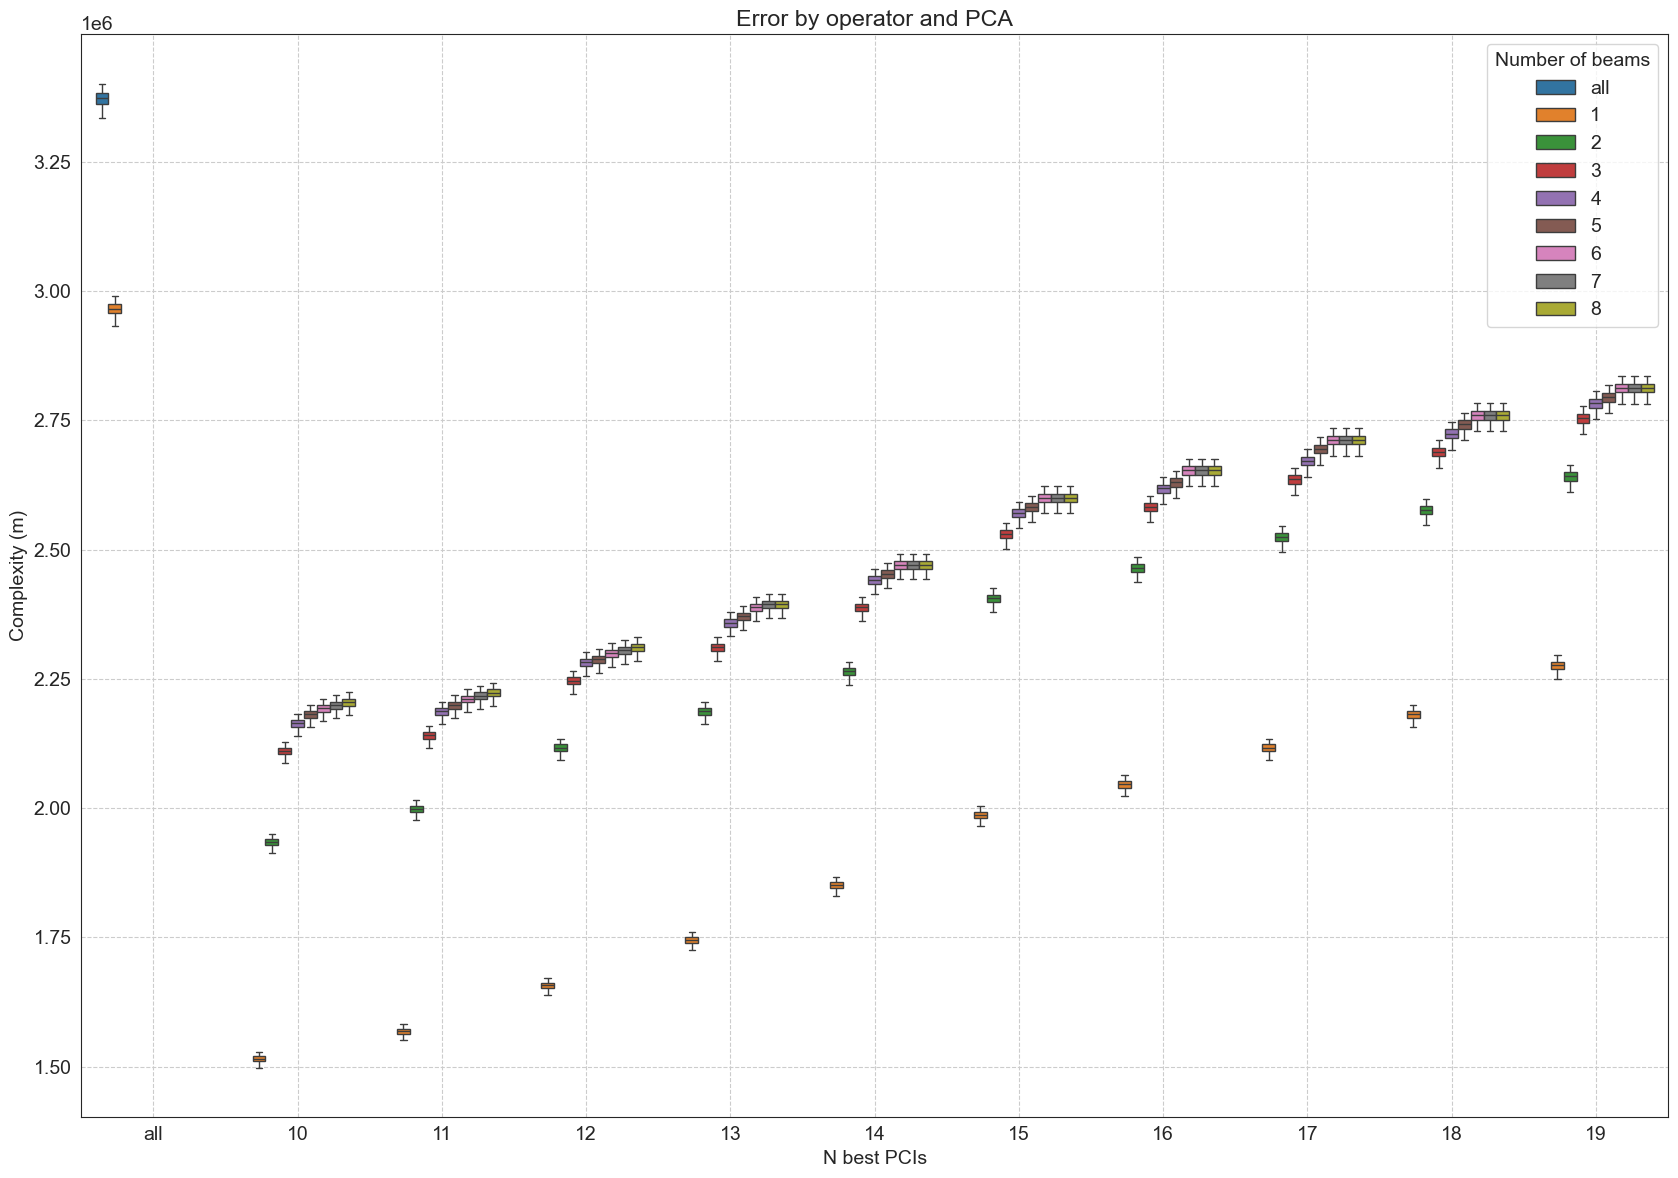

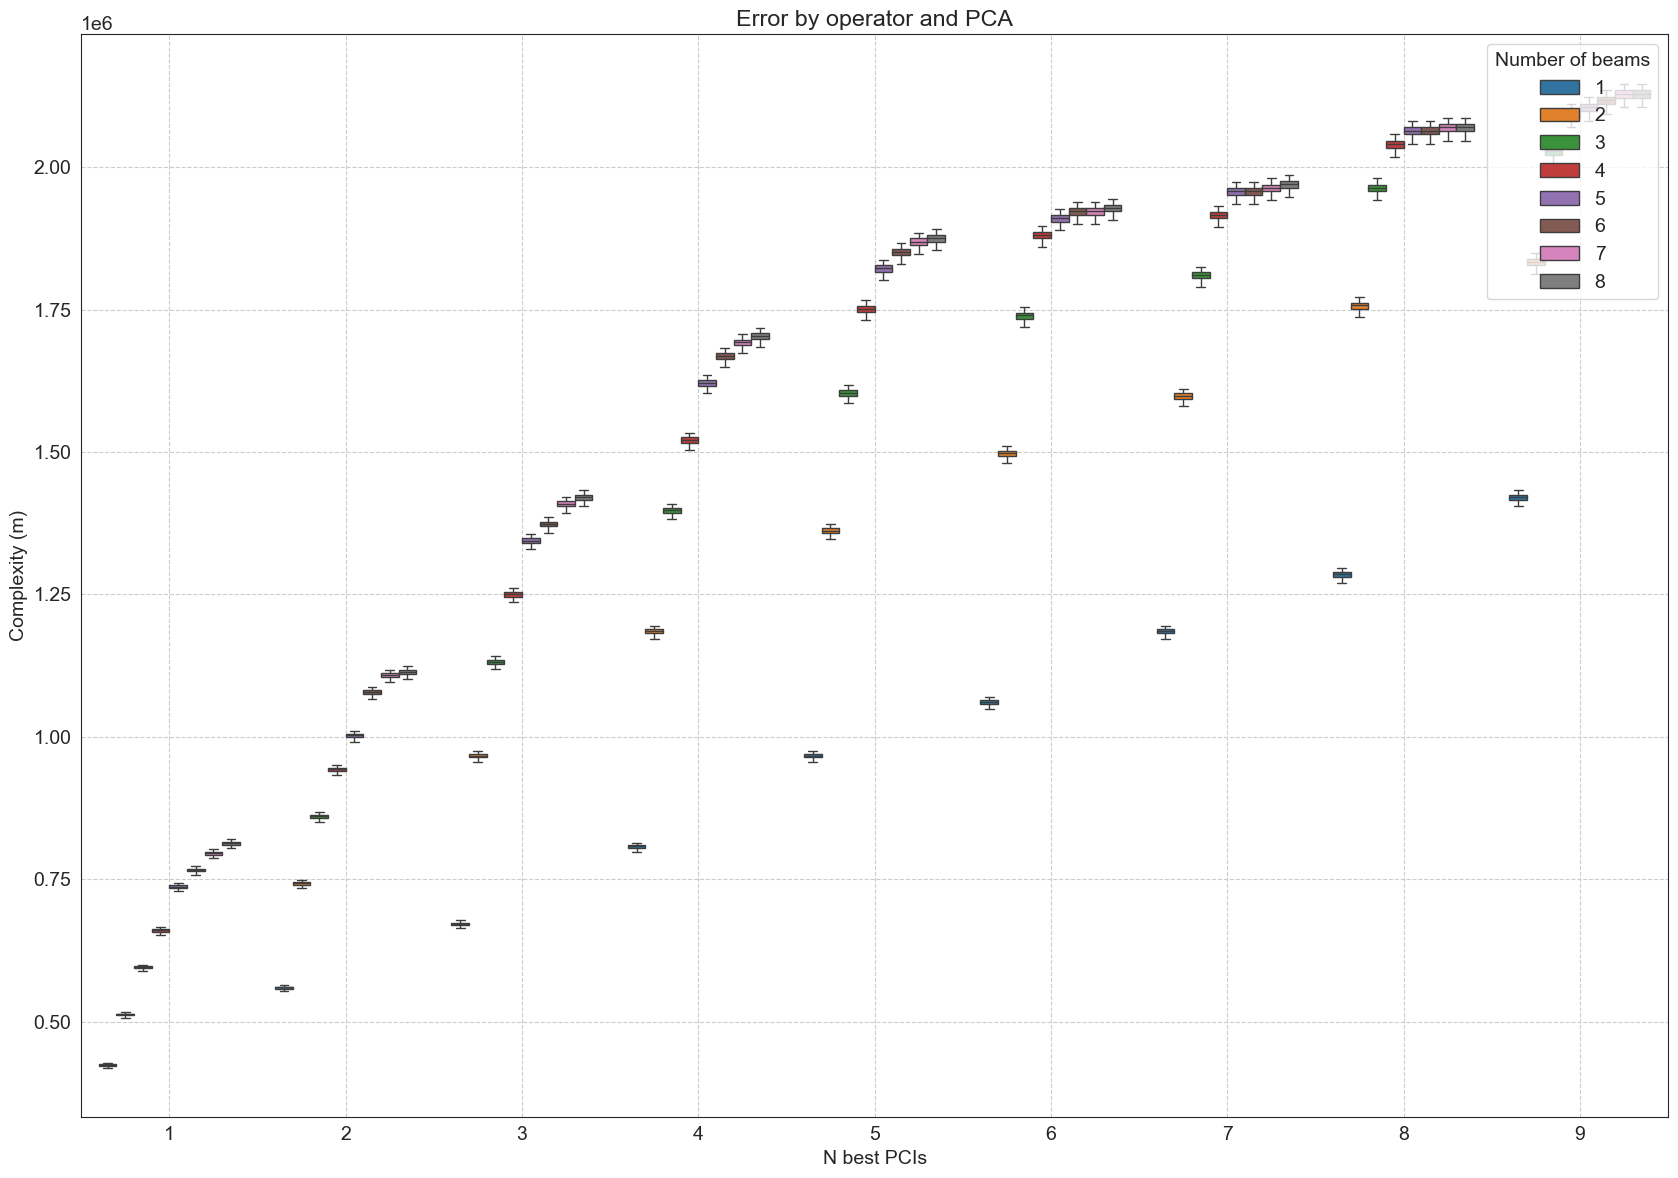

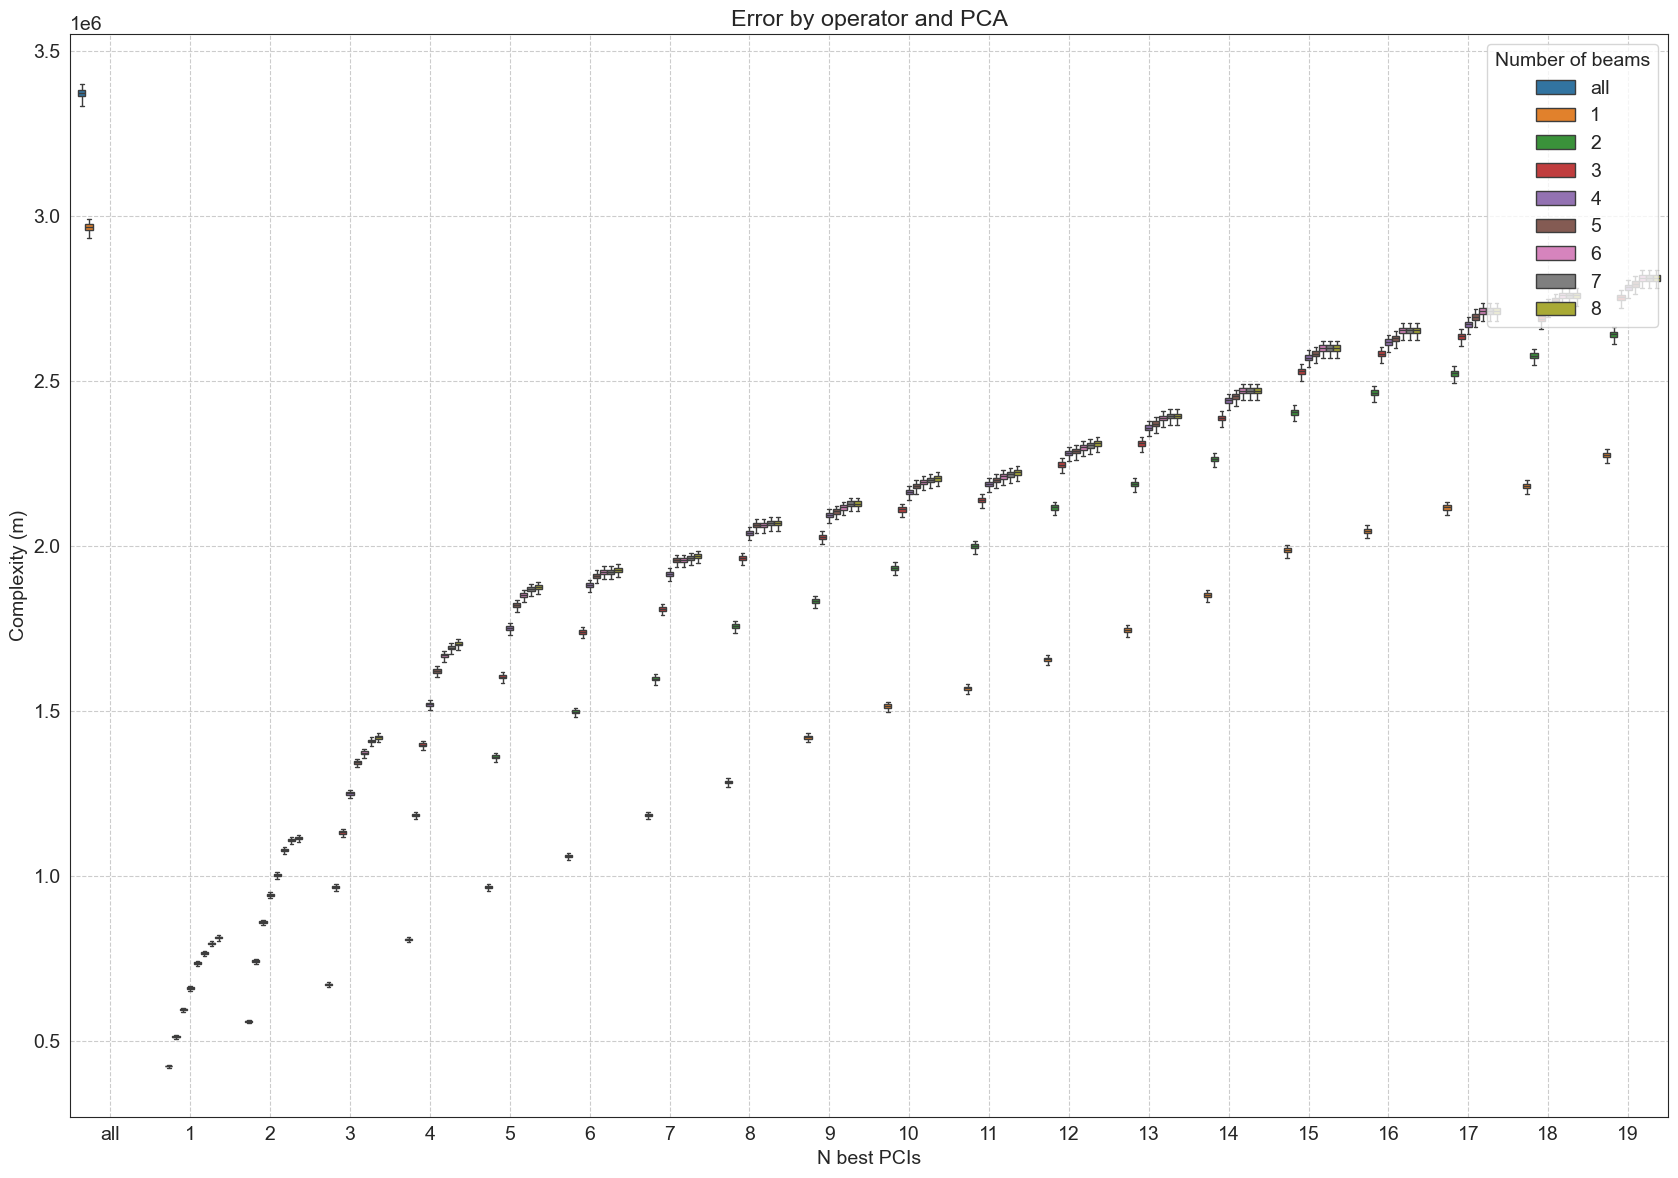

In [68]:

def plot_complexity(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 14})

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='complexity',
        hue='n_best_beams',
        showfliers=False,
    )

    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Complexity (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 20)] + ['all']
lows = [str(i) for i in range(1, 10)]


def plottt(df):
    plot_complexity(df[df['n_best_pcis'].isin(highs)])
    plot_complexity(df[df['n_best_pcis'].isin(lows)])
    plot_complexity(df)


plottt(data_df)

In [77]:
data_df.groupby(['operator', 'config', 'run'])['runtime'].count()

operator  config                            run
1         All PCIs and all beams            0.0    2517
                                            1.0    2585
                                            2.0    2537
                                            3.0    2469
                                            4.0    2537
                                                   ... 
88        Only best PCI and only best beam  5.0    2518
                                            6.0    2518
                                            7.0    2502
                                            8.0    2650
                                            9.0    2499
Name: runtime, Length: 160, dtype: int64